# Proyecto Hermes — Kalman GPS + IMU

Este notebook responde una pregunta concreta: **¿conviene fusionar GPS con
IMU (acelerómetro + giroscopio + magnetómetro) para el aeroplano de Hermes,
y cuánto aporta realmente?**

Todavía no hay NEO-6M, pero si MPU9250 por el momento, así que todo se prueba acá con
datos sintéticos (trayectorias simuladas + ruido de sensor de datasheet)
hasta que llegue el gps. Ademas como ayuda de referencia de la ruta para este proyecto, se encuentra el csv de perfil_trayectoria, el cual contiene una trayectoria con datos sinteticos desde Santo Domingo a la cordillera de los andes(justo antes de llegar a argentina), en conjunto con su perfil de altitud promedio, y el gpx con los links correspondientes para una mayor visualizacion, esto con el fin de mayor contextualizacion(no se usara el data set para las siguientes simulaciones).

**Qué encontrar, en orden:**

1. **El filtro** — diseño del filtro de Kalman GPS+IMU que se usaría en
   producción (posición, velocidad y bias del acelerómetro re-estimado en
   vuelo).
2. **Los dos casos de la misión** — reviente de emergencia vs. "suelta"
   controlada del aeroplano, y cuánto mejora cada uno con el IMU en el loop.
3. **AHRS (Madgwick)** — qué pasa cuando el aeroplano ya vuela solo y
   maniobra de verdad (vira con roll), y por qué ahí no alcanza con el atajo
   de "solo yaw" que se usa en los casos anteriores.
4. **Próximos pasos** — qué falta antes de llevar esto a producción.
5. **Diccionario de términos** y **procedencia del código** — para que
   cualquiera pueda entender el notebook sin dar por sabido el vocabulario
   ni de dónde salió cada pedazo de código.


In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np


## Kalman GPS + IMU

La secuencia real tiene dos formas de terminar la fase de ascenso:

- **Caso emergencia**: el globo revienta de forma no planeada. El aeroplano
  activa sus módulos de emergencia (estabilización/despliegue) y pasa a vuelo
  controlado. Es el escenario más violento — caída libre, posible tumbo,
  mayor chance de perder señal GPS justo por la sacudida.
- **Caso controlado (exitoso)**: el globo sigue entero; el aeroplano se
  libera por comando, de forma planeada (aún por decidir, preguntar). Mucho
  menos violento, y se sabe el instante exacto porque es un comando, no un
  evento aleatorio.

Ambos casos rompen la suposición de "velocidad constante" que usa un filtro
de solo-GPS, así que en los dos vale la pena tener el IMU en el loop — la
pregunta que responde esta sección es **cuánto** vale la pena en cada uno.


## El filtro: GPS + IMU con bias re-estimado en vuelo

**Diseño**: un solo filtro de Kalman lineal (no hace falta EKF completo, ver
nota abajo), el mismo para ambos casos, con estado de 9 dimensiones:

```
[x, vx, y, vy, z, vz, bias_ax, bias_ay, bias_az]
```

- `x, y, z` / `vx, vy, vz`: posición y velocidad en un marco local en metros
  (este/norte/altitud), no en grados de lat/lon.
- `bias_ax, bias_ay, bias_az`: el bias del acelerómetro, tratado como parte
  del estado (random walk lento) para que el filtro lo vaya re-estimando
  solo cada vez que hay GPS disponible, en vez de asumirlo fijo. Sin esto, un
  bias sin corregir se integra dos veces (aceleración → velocidad → posición)
  y el error crece con el **cuadrado** del tiempo.
- **Predict**: a cada muestra del IMU (50 Hz), se usa la aceleración medida
  (ya corregida del bias estimado) como *control input* — así el filtro sigue
  el movimiento real en vez de solo asumir velocidad constante.
- **Update**: cada vez que llega un fix GPS (1 Hz) válido, se corrige
  posición y velocidad, y de paso el filtro aprende un poco más sobre el bias
  real del acelerómetro.

**Simplificación usada**: para rotar la aceleración del marco
del sensor al marco terrestre solo se integra el *yaw* del giroscopio,
asumiendo roll/pitch ≈ 0. Válido mientras el payload cuelga nivelado de la
línea del globo; **no** es válido una vez que el aeroplano vuela solo y vira
con roll real — para esa fase hace falta actitud 3D completa (ver "Próximos
pasos" al final).

In [2]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise


def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))


def crear_filtro_cv3d(dt, sigma_h, sigma_v, x0, proceso_var=0.5):
    """
    Filtro de velocidad constante, solo GPS (sin IMU). Sirve como referencia
    para medir cuánto aporta el IMU, y como plan B si el IMU falla en vuelo.
    Estado: [x, vx, y, vy, z, vz]
    """
    kf = KalmanFilter(dim_x=6, dim_z=3)

    kf.F = np.eye(6)
    for i in (0, 2, 4):
        kf.F[i, i + 1] = dt

    kf.H = np.zeros((3, 6))
    kf.H[0, 0] = 1.0
    kf.H[1, 2] = 1.0
    kf.H[2, 4] = 1.0

    kf.R = np.diag([sigma_h**2, sigma_h**2, sigma_v**2])

    q_xy = Q_discrete_white_noise(dim=2, dt=dt, var=proceso_var)
    kf.Q = np.zeros((6, 6))
    kf.Q[0:2, 0:2] = q_xy
    kf.Q[2:4, 2:4] = q_xy
    kf.Q[4:6, 4:6] = q_xy

    kf.P *= 100.0
    kf.x = np.array([x0[0], 0., x0[1], 0., x0[2], 0.])
    return kf

In [3]:
def crear_filtro_ca3d_bias(dt, sigma_h, sigma_v, x0, proceso_var=0.1, bias_randomwalk_std=0.0005):
    """
    El filtro que se usaría en producción: GPS + IMU, con el bias del
    acelerómetro como parte del estado (9 dim).
    Estado: [x, vx, y, vy, z, vz, bias_ax, bias_ay, bias_az]
    Control u: aceleración CRUDA medida (sin corregir), en marco mundo.
    """
    kf = KalmanFilter(dim_x=9, dim_z=3, dim_u=3)

    kf.F = np.eye(9)
    for i in (0, 2, 4):
        kf.F[i, i + 1] = dt

    B6 = np.zeros((6, 3))
    for fila_x, fila_v, col in ((0, 1, 0), (2, 3, 1), (4, 5, 2)):
        B6[fila_x, col] = 0.5 * dt ** 2
        B6[fila_v, col] = dt

    # x_siguiente = F·x + B·u_cruda = (CV normal) - B·bias + B·u_cruda
    #             = (CV normal) + B·(u_cruda - bias)   <- justo lo que queremos
    kf.F[0:6, 6:9] = -B6
    kf.B = np.zeros((9, 3))
    kf.B[0:6, :] = B6

    kf.H = np.zeros((3, 9))
    kf.H[0, 0] = 1.0
    kf.H[1, 2] = 1.0
    kf.H[2, 4] = 1.0

    kf.R = np.diag([sigma_h ** 2, sigma_h ** 2, sigma_v ** 2])

    q_1d = Q_discrete_white_noise(dim=2, dt=dt, var=proceso_var)
    kf.Q = np.zeros((9, 9))
    kf.Q[0:2, 0:2] = q_1d
    kf.Q[2:4, 2:4] = q_1d
    kf.Q[4:6, 4:6] = q_1d
    kf.Q[6:9, 6:9] = np.eye(3) * (bias_randomwalk_std ** 2)  # el bias se mueve muy despacio

    kf.P *= 100.0
    kf.P[6:9, 6:9] = np.eye(3) * (0.2 ** 2)  # arranca sin saber nada del bias
    kf.x = np.zeros(9)
    kf.x[0], kf.x[2], kf.x[4] = x0
    return kf

In [4]:
# --- Parámetros de sensor (valores de datasheet — recalibrar con mediciones reales) ---
FS_GPS = 1.0    # Hz, frecuencia de fix del NEO-6M
FS_IMU = 50.0   # Hz, típico de un MPU9250
G = 9.81        # m/s²

# NEO-6M sin SBAS/DGPS: ~2.5 m CEP horizontal (CEP50 = 1.1774 * sigma)
CEP_HORIZONTAL_M = 2.5
SIGMA_H = CEP_HORIZONTAL_M / 1.1774    # ~2.1 m por eje (x e y)
SIGMA_V = 6.0                           # m, ruido típico de altitud GPS

# MPU9250
ACCEL_NOISE_STD = 0.05             # m/s², ruido blanco típico de un MEMS accel
ACCEL_BIAS_RESIDUAL = 0.02         # m/s², bias residual asumiendo calibración al encender
GYRO_NOISE_STD = np.radians(0.5)   # rad/s
GYRO_BIAS = np.radians(0.3)        # rad/s, deriva típica de giroscopio MEMS

## Arnés de simulación

Una sola función que arma la "verdad" a partir de un perfil de velocidad
(waypoints), simula GPS+IMU ruidosos con un corte de señal, y corre los dos
filtros (solo-GPS vs GPS+IMU) para comparar. Así el mismo código sirve para
cualquier escenario — solo cambian los waypoints y la ventana del corte.

In [5]:
def integrar_posicion(v, t, x0):
    dt = np.diff(t)
    incrementos = 0.5 * (v[:-1] + v[1:]) * dt
    return x0 + np.concatenate(([0.0], np.cumsum(incrementos)))


def simular_escenario(nombre, t_wp, vz_wp, vx_wp, vy_wp, duracion_s,
                       dropout_inicio_s, dropout_fin_s, z0=3500.0, seed=99):
    """
    Genera la verdad de vuelo a partir de waypoints de velocidad (t, v),
    simula fixes GPS e IMU ruidosos con un corte de señal, y corre solo-GPS
    (coasting) vs GPS+IMU (bias re-estimado). Devuelve un dict con todo lo
    necesario para graficar y comparar.
    """
    t_imu = np.arange(0.0, duracion_s, 1.0 / FS_IMU)
    vx_true = np.interp(t_imu, t_wp, vx_wp)
    vy_true = np.interp(t_imu, t_wp, vy_wp)
    vz_true = np.interp(t_imu, t_wp, vz_wp)

    x_true = integrar_posicion(vx_true, t_imu, 0.0)
    y_true = integrar_posicion(vy_true, t_imu, 0.0)
    z_true = integrar_posicion(vz_true, t_imu, z0)

    ax_true = np.gradient(vx_true, t_imu)
    ay_true = np.gradient(vy_true, t_imu)
    az_true = np.gradient(vz_true, t_imu)
    yaw_true = np.unwrap(np.arctan2(vy_true, vx_true))
    gyro_z_true = np.gradient(yaw_true, t_imu)

    imu_por_gps = int(round(FS_IMU / FS_GPS))
    idx_gps = np.arange(0, len(t_imu), imu_por_gps)
    idx_gps_set = {i: k for k, i in enumerate(idx_gps)}
    t_gps = t_imu[idx_gps]
    x_gps_true, y_gps_true, z_gps_true = x_true[idx_gps], y_true[idx_gps], z_true[idx_gps]

    rng = np.random.default_rng(seed)
    x_gps_meas = x_gps_true + rng.normal(0, SIGMA_H, size=x_gps_true.shape)
    y_gps_meas = y_gps_true + rng.normal(0, SIGMA_H, size=y_gps_true.shape)
    z_gps_meas = z_gps_true + rng.normal(0, SIGMA_V, size=z_gps_true.shape)
    gps_disponible = ~((t_gps >= dropout_inicio_s) & (t_gps < dropout_fin_s))

    cos_y, sin_y = np.cos(yaw_true), np.sin(yaw_true)
    ax_body = ax_true * cos_y + ay_true * sin_y
    ay_body = -ax_true * sin_y + ay_true * cos_y
    az_body = az_true + G  # el acelerómetro mide fuerza específica: +G en reposo

    ax_meas = ax_body + ACCEL_BIAS_RESIDUAL + rng.normal(0, ACCEL_NOISE_STD, size=t_imu.shape)
    ay_meas = ay_body + ACCEL_BIAS_RESIDUAL + rng.normal(0, ACCEL_NOISE_STD, size=t_imu.shape)
    az_meas = az_body + rng.normal(0, ACCEL_NOISE_STD, size=t_imu.shape)
    gyro_z_meas = gyro_z_true + GYRO_BIAS + rng.normal(0, GYRO_NOISE_STD, size=t_imu.shape)

    dt_imu = 1.0 / FS_IMU

    # --- Filtro A: solo GPS (coasting) ---
    kf_coast = crear_filtro_cv3d(dt=1.0 / FS_GPS, sigma_h=SIGMA_H, sigma_v=SIGMA_V,
                                  x0=(x_gps_meas[0], y_gps_meas[0], z_gps_meas[0]))
    coast_z = []
    for k in range(len(t_gps)):
        kf_coast.predict()
        if gps_disponible[k]:
            kf_coast.update(np.array([x_gps_meas[k], y_gps_meas[k], z_gps_meas[k]]))
        coast_z.append(kf_coast.x[4])
    coast_z = np.array(coast_z)

    # --- Filtro B: GPS + IMU (bias re-estimado) ---
    kf_fusion = crear_filtro_ca3d_bias(dt=dt_imu, sigma_h=SIGMA_H, sigma_v=SIGMA_V,
                                        x0=(x_gps_meas[0], y_gps_meas[0], z_gps_meas[0]))
    yaw_hat = yaw_true[0]
    ultimo_x_gps, ultimo_y_gps = x_gps_meas[0], y_gps_meas[0]
    fusion_z = []
    for i in range(len(t_imu)):
        yaw_hat += gyro_z_meas[i] * dt_imu
        ax_w = ax_meas[i] * np.cos(yaw_hat) - ay_meas[i] * np.sin(yaw_hat)
        ay_w = ax_meas[i] * np.sin(yaw_hat) + ay_meas[i] * np.cos(yaw_hat)
        az_w = az_meas[i] - G

        kf_fusion.predict(u=np.array([ax_w, ay_w, az_w]))

        if i in idx_gps_set:
            k = idx_gps_set[i]
            if gps_disponible[k]:
                kf_fusion.update(np.array([x_gps_meas[k], y_gps_meas[k], z_gps_meas[k]]))
                dx, dy = x_gps_meas[k] - ultimo_x_gps, y_gps_meas[k] - ultimo_y_gps
                if np.hypot(dx, dy) > 3.0:
                    yaw_hat = np.arctan2(dy, dx)
                ultimo_x_gps, ultimo_y_gps = x_gps_meas[k], y_gps_meas[k]

        fusion_z.append(kf_fusion.x[4])
    fusion_z = np.array(fusion_z)

    en_corte_gps = (t_gps >= dropout_inicio_s) & (t_gps < dropout_fin_s)
    en_corte_imu = (t_imu >= dropout_inicio_s) & (t_imu < dropout_fin_s)
    err_coast = np.abs(coast_z - z_gps_true)
    err_fusion = np.abs(fusion_z - z_true)

    return {
        "nombre": nombre, "t_imu": t_imu, "t_gps": t_gps,
        "z_true": z_true, "z_gps_meas": z_gps_meas,
        "coast_z": coast_z, "fusion_z": fusion_z,
        "gps_disponible": gps_disponible,
        "dropout_inicio_s": dropout_inicio_s, "dropout_fin_s": dropout_fin_s,
        "err_coast": err_coast, "err_fusion": err_fusion,
        "rmse_coast": rmse(err_coast[en_corte_gps], 0),
        "rmse_fusion": rmse(err_fusion[en_corte_imu], 0),
        "max_coast": err_coast[en_corte_gps].max(),
        "max_fusion": err_fusion[en_corte_imu].max(),
    }

## Caso 1 — Emergencia: reviente no planeado

El globo revienta sin aviso. El aeroplano cae libre unos segundos y luego
activa sus módulos de emergencia (estabilización/despliegue) para pasar a
vuelo controlado. Es el escenario más violento — y el más propenso a perder
señal GPS por la sacudida de la explosión — así que se simula un corte largo
(22 s) justo alrededor del evento.

**Parámetros ilustrativos** — reemplazar por los reales apenas se definan
altura de reviente, tiempos de caída libre y despliegue del sistema de
emergencia.

In [6]:
T_REVIENTA = 120.0
T_CAIDA_LIBRE = 5.0     # s, antes de que actúen los módulos de emergencia
T_ESTABILIZACION = 10.0  # s, lo que tardan en frenar la caída libre a planeo estable

VZ_ASCENSO = 5.0
VZ_PLANEO = -8.0
VZ_CAIDA_LIBRE = VZ_ASCENSO - G * T_CAIDA_LIBRE

t1 = T_REVIENTA
t2 = t1 + T_CAIDA_LIBRE
t3 = t2 + T_ESTABILIZACION

resultado_A = simular_escenario(
    nombre="Emergencia (reviente)",
    t_wp=[0.0, t1, t2, t3, 260.0],
    vz_wp=[VZ_ASCENSO, VZ_ASCENSO, VZ_CAIDA_LIBRE, VZ_PLANEO, VZ_PLANEO],
    vx_wp=[2.0, 2.0, -2.0, 12.0, 12.0],   # deriva del viento -> tumbo breve -> planeo estable
    vy_wp=[1.5, 1.5, 1.5, 9.0, 9.0],
    duracion_s=260.0,
    dropout_inicio_s=T_REVIENTA - 2.0,     # el tumbo afecta la antena un poco antes del reviente
    dropout_fin_s=t3 + 5.0,                # se recupera unos segundos después de estabilizar
)

print(f"[{resultado_A['nombre']}] corte de GPS: "
      f"{resultado_A['dropout_fin_s'] - resultado_A['dropout_inicio_s']:.0f} s")
print(f"  Error de altitud — solo GPS: {resultado_A['rmse_coast']:7.1f} m (máx {resultado_A['max_coast']:.0f} m)")
print(f"  Error de altitud — GPS+IMU:  {resultado_A['rmse_fusion']:7.1f} m (máx {resultado_A['max_fusion']:.0f} m)")

[Emergencia (reviente)] corte de GPS: 22 s
  Error de altitud — solo GPS:   310.3 m (máx 498 m)
  Error de altitud — GPS+IMU:      5.6 m (máx 9 m)


## Caso 2 — Controlado (exitoso)

El globo sigue entero; el aeroplano se libera por comando en un instante
conocido (`T_SUELTA`), y transiciona en pocos segundos a vuelo propio — sin
caída libre, porque el sistema está diseñado para tomar control apenas se
suelta. Al ser un evento comandado (no una explosión), se simula un corte de
GPS más corto y menos severo (7 s), solo como margen de seguridad por la
vibración de la suelta mecánica.

In [7]:
T_SUELTA = 100.0
T_TRANSICION = 4.0  # s, mucho más rápido y suave que la emergencia: sin caída libre

resultado_B = simular_escenario(
    nombre="Suelta controlada",
    t_wp=[0.0, T_SUELTA, T_SUELTA + T_TRANSICION, 200.0],
    vz_wp=[5.0, 5.0, -8.0, -8.0],           # transición directa a planeo, sin caída libre
    vx_wp=[2.0, 2.0, 12.0, 12.0],
    vy_wp=[1.5, 1.5, 9.0, 9.0],
    duracion_s=200.0,
    dropout_inicio_s=T_SUELTA - 1.0,
    dropout_fin_s=T_SUELTA + T_TRANSICION + 3.0,
)

print(f"[{resultado_B['nombre']}] corte de GPS: "
      f"{resultado_B['dropout_fin_s'] - resultado_B['dropout_inicio_s']:.0f} s")
print(f"  Error de altitud — solo GPS: {resultado_B['rmse_coast']:7.1f} m (máx {resultado_B['max_coast']:.0f} m)")
print(f"  Error de altitud — GPS+IMU:  {resultado_B['rmse_fusion']:7.1f} m (máx {resultado_B['max_fusion']:.0f} m)")

[Suelta controlada] corte de GPS: 8 s
  Error de altitud — solo GPS:    33.9 m (máx 65 m)
  Error de altitud — GPS+IMU:      1.5 m (máx 2 m)


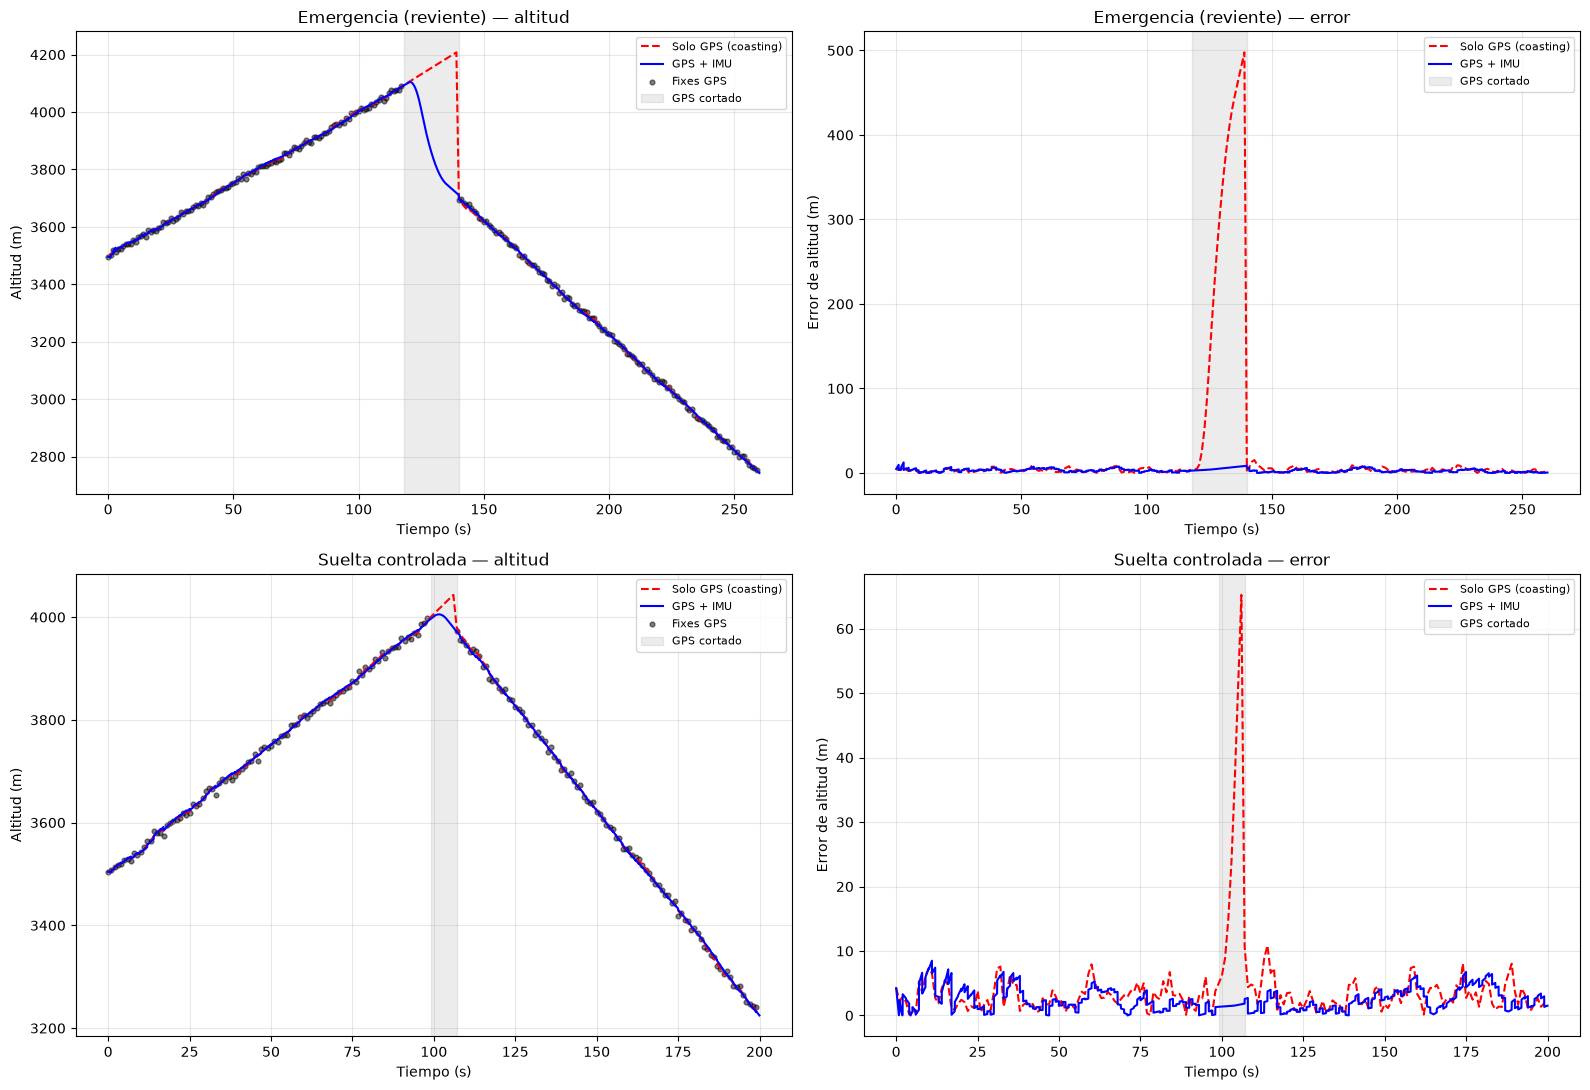

Escenario                Corte GPS    Error solo-GPS     Error GPS+IMU    Mejora
Emergencia (reviente)         22 s          310.3 m            5.6 m     55.8x
Suelta controlada              8 s           33.9 m            1.5 m     22.0x


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for fila, r in enumerate([resultado_A, resultado_B]):
    ax_alt, ax_err = axes[fila]

    ax_alt.plot(r["t_gps"], r["coast_z"], 'r--', linewidth=1.5, label='Solo GPS (coasting)')
    ax_alt.plot(r["t_imu"], r["fusion_z"], 'b-', linewidth=1.5, label='GPS + IMU')
    disp = r["gps_disponible"]
    ax_alt.scatter(r["t_gps"][disp], r["z_gps_meas"][disp], s=12, color='black', alpha=0.5, label='Fixes GPS')
    ax_alt.axvspan(r["dropout_inicio_s"], r["dropout_fin_s"], color='gray', alpha=0.15, label='GPS cortado')
    ax_alt.set_xlabel('Tiempo (s)'); ax_alt.set_ylabel('Altitud (m)')
    ax_alt.set_title(f'{r["nombre"]} — altitud'); ax_alt.legend(fontsize=8); ax_alt.grid(alpha=0.3)

    ax_err.plot(r["t_gps"], r["err_coast"], 'r--', label='Solo GPS (coasting)')
    ax_err.plot(r["t_imu"], r["err_fusion"], 'b-', label='GPS + IMU')
    ax_err.axvspan(r["dropout_inicio_s"], r["dropout_fin_s"], color='gray', alpha=0.15, label='GPS cortado')
    ax_err.set_xlabel('Tiempo (s)'); ax_err.set_ylabel('Error de altitud (m)')
    ax_err.set_title(f'{r["nombre"]} — error'); ax_err.legend(fontsize=8); ax_err.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_emergencia_vs_suelta.png', dpi=150)
plt.show()

print(f"{'Escenario':<22}{'Corte GPS':>12}{'Error solo-GPS':>18}{'Error GPS+IMU':>18}{'Mejora':>10}")
for r in [resultado_A, resultado_B]:
    corte = r['dropout_fin_s'] - r['dropout_inicio_s']
    mejora = r['rmse_coast'] / r['rmse_fusion']
    print(f"{r['nombre']:<22}{corte:>10.0f} s{r['rmse_coast']:>15.1f} m{r['rmse_fusion']:>15.1f} m{mejora:>9.1f}x")

## Conclusión: mismo filtro, distinto margen de beneficio

Con el mismo diseño de filtro corriendo en los dos casos:

- **Emergencia**: corte largo + dinámica violenta (caída libre) → el IMU es
  la diferencia entre saber dónde está el aeroplano y perderlo por completo
  durante el corte.
- **Suelta controlada**: corte corto + transición suave → el IMU sigue
  ayudando (menos error, más consistente), pero el margen es mucho menor,
  porque el GPS casi no llega a perder el hilo.

La conclusión práctica: **no hace falta un filtro distinto para cada caso** —
el mismo diseño (GPS + IMU con bias re-estimado) cubre ambos, y su beneficio
escala solo con qué tan violento es el evento y qué tan mala es la pérdida de
señal en cada uno. Como el costo de tenerlo corriendo siempre es bajo
(ya está implementado), tiene sentido dejarlo activo todo el vuelo en vez de
intentar activarlo solo para el caso de emergencia.

## Implementación con AHRS (Madgwick)

Todo lo anterior asumió roll/pitch ≈ 0 (válido colgando nivelado del globo).
Acá se prueba qué pasa cuando eso deja de ser cierto: el aeroplano ya está
volando solo y hace un **viraje inclinado** (banking turn) — algo que
cualquier aeroplano real hace todo el tiempo para girar (según la
investigación preliminar).

Se comparan dos formas de reconstruir la aceleración en marco mundo a partir
del acelerómetro:

1. **El atajo actual** (solo yaw, ignora el roll) — el mismo que usa
   `simular_escenario` en todo este notebook.
2. **AHRS real** (Madgwick, fusionando acelerómetro + giroscopio +
   magnetómetro) — estima actitud completa (roll/pitch/yaw) como un
   quaternion, y con eso sí se puede rotar correctamente.

Las dos reconstrucciones se meten al mismo filtro de posición
(`crear_filtro_ca3d_bias`) y se compara el error resultante durante el
viraje. Esta vez el GPS está disponible todo el tiempo (sin corte) —
justamente para aislar el efecto de la actitud mal estimada, sin mezclarlo
con el problema de pérdida de señal que ya se probó antes.


In [9]:
def madgwick_update(q, gyro, accel, mag, dt, beta=0.05):
    """
    Un paso del filtro de Madgwick (AHRS de 9 ejes: accel + gyro + mag).
    q: quaternion [q0,q1,q2,q3] (escalar primero), rotación cuerpo -> mundo.
    Devuelve el quaternion actualizado (normalizado).
    """
    q0, q1, q2, q3 = q
    gx, gy, gz = gyro
    ax, ay, az = accel
    mx, my, mz = mag

    qDot1 = 0.5 * (-q1*gx - q2*gy - q3*gz)
    qDot2 = 0.5 * (q0*gx + q2*gz - q3*gy)
    qDot3 = 0.5 * (q0*gy - q1*gz + q3*gx)
    qDot4 = 0.5 * (q0*gz + q1*gy - q2*gx)

    norm_a = math.sqrt(ax*ax + ay*ay + az*az)
    if norm_a > 0:
        ax, ay, az = ax/norm_a, ay/norm_a, az/norm_a
        norm_m = math.sqrt(mx*mx + my*my + mz*mz)
        mx, my, mz = mx/norm_m, my/norm_m, mz/norm_m

        _2q0mx, _2q0my, _2q0mz = 2*q0*mx, 2*q0*my, 2*q0*mz
        _2q1mx = 2*q1*mx
        _2q0, _2q1, _2q2, _2q3 = 2*q0, 2*q1, 2*q2, 2*q3
        q0q0, q0q1, q0q2, q0q3 = q0*q0, q0*q1, q0*q2, q0*q3
        q1q1, q1q2, q1q3 = q1*q1, q1*q2, q1*q3
        q2q2, q2q3 = q2*q2, q2*q3
        q3q3 = q3*q3

        hx = mx*q0q0 - _2q0my*q3 + _2q0mz*q2 + mx*q1q1 + _2q1*my*q2 + _2q1*mz*q3 - mx*q2q2 - mx*q3q3
        hy = _2q0mx*q3 + my*q0q0 - _2q0mz*q1 + _2q1mx*q2 - my*q1q1 + my*q2q2 + _2q2*mz*q3 - my*q3q3
        _2bx = math.sqrt(hx*hx + hy*hy)
        _2bz = -_2q0mx*q2 + _2q0my*q1 + mz*q0q0 + _2q1mx*q3 - mz*q1q1 + _2q2*my*q3 - mz*q2q2 + mz*q3q3
        _4bx, _4bz = 2*_2bx, 2*_2bz

        s0 = (-_2q2*(2*(q1q3 - q0q2) - ax) + _2q1*(2*(q0q1 + q2q3) - ay)
              - _2bz*q2*(_2bx*(0.5 - q2q2 - q3q3) + _2bz*(q1q3 - q0q2) - mx)
              + (-_2bx*q3 + _2bz*q1)*(_2bx*(q1q2 - q0q3) + _2bz*(q0q1 + q2q3) - my)
              + _2bx*q2*(_2bx*(q0q2 + q1q3) + _2bz*(0.5 - q1q1 - q2q2) - mz))
        s1 = (_2q3*(2*(q1q3 - q0q2) - ax) + _2q0*(2*(q0q1 + q2q3) - ay) - 4*q1*(1 - 2*(q1q1 + q2q2) - az)
              + _2bz*q3*(_2bx*(0.5 - q2q2 - q3q3) + _2bz*(q1q3 - q0q2) - mx)
              + (_2bx*q2 + _2bz*q0)*(_2bx*(q1q2 - q0q3) + _2bz*(q0q1 + q2q3) - my)
              + (_2bx*q3 - _4bz*q1)*(_2bx*(q0q2 + q1q3) + _2bz*(0.5 - q1q1 - q2q2) - mz))
        s2 = (-_2q0*(2*(q1q3 - q0q2) - ax) + _2q3*(2*(q0q1 + q2q3) - ay) - 4*q2*(1 - 2*(q1q1 + q2q2) - az)
              + (-_4bx*q2 - _2bz*q0)*(_2bx*(0.5 - q2q2 - q3q3) + _2bz*(q1q3 - q0q2) - mx)
              + (_2bx*q1 + _2bz*q3)*(_2bx*(q1q2 - q0q3) + _2bz*(q0q1 + q2q3) - my)
              + (_2bx*q0 - _4bz*q2)*(_2bx*(q0q2 + q1q3) + _2bz*(0.5 - q1q1 - q2q2) - mz))
        s3 = (_2q1*(2*(q1q3 - q0q2) - ax) + _2q2*(2*(q0q1 + q2q3) - ay)
              + (-_4bx*q3 + _2bz*q1)*(_2bx*(0.5 - q2q2 - q3q3) + _2bz*(q1q3 - q0q2) - mx)
              + (-_2bx*q0 + _2bz*q2)*(_2bx*(q1q2 - q0q3) + _2bz*(q0q1 + q2q3) - my)
              + _2bx*q1*(_2bx*(q0q2 + q1q3) + _2bz*(0.5 - q1q1 - q2q2) - mz))

        norm_s = math.sqrt(s0*s0 + s1*s1 + s2*s2 + s3*s3)
        if norm_s > 0:
            s0, s1, s2, s3 = s0/norm_s, s1/norm_s, s2/norm_s, s3/norm_s

        qDot1 -= beta * s0
        qDot2 -= beta * s1
        qDot3 -= beta * s2
        qDot4 -= beta * s3

    q0 += qDot1 * dt
    q1 += qDot2 * dt
    q2 += qDot3 * dt
    q3 += qDot4 * dt
    norm_q = math.sqrt(q0*q0 + q1*q1 + q2*q2 + q3*q3)
    return np.array([q0, q1, q2, q3]) / norm_q


def quat_a_R(q):
    """Matriz de rotación cuerpo -> mundo a partir del quaternion."""
    q0, q1, q2, q3 = q
    return np.array([
        [1 - 2*(q2**2 + q3**2), 2*(q1*q2 - q0*q3),     2*(q1*q3 + q0*q2)],
        [2*(q1*q2 + q0*q3),     1 - 2*(q1**2 + q3**2), 2*(q2*q3 - q0*q1)],
        [2*(q1*q3 - q0*q2),     2*(q2*q3 + q0*q1),     1 - 2*(q1**2 + q2**2)],
    ])

### Escenario: viraje inclinado en pleno planeo

Vuelo recto → banca a 35° de roll durante un viraje de 90° de rumbo → vuelve
a nivelarse. Velocidad de planeo constante (15 m/s horizontal, -8 m/s
vertical). **Parámetros ilustrativos**, igual que el resto del notebook.

In [10]:
DURACION_MANIOBRA_S = 40.0
SPEED_PLANEO = 15.0  # m/s, rapidez horizontal de planeo (constante)

t_m = np.arange(0.0, DURACION_MANIOBRA_S, 1.0 / FS_IMU)

roll_true = np.radians(np.interp(t_m, [0, 10, 12, 20, 22, 40], [0, 0, 35, 35, 0, 0]))
pitch_true = np.zeros_like(t_m)   # se aísla el efecto del roll; pitch=0 en todo el vuelo
yaw_true_m = np.radians(np.interp(t_m, [0, 10, 20, 22, 40], [0, 0, 90, 90, 90]))

vx_true_m = SPEED_PLANEO * np.cos(yaw_true_m)
vy_true_m = SPEED_PLANEO * np.sin(yaw_true_m)
vz_true_m = -8.0 * np.ones_like(t_m)

x_true_m = integrar_posicion(vx_true_m, t_m, 0.0)
y_true_m = integrar_posicion(vy_true_m, t_m, 0.0)
z_true_m = integrar_posicion(vz_true_m, t_m, 3000.0)

ax_true_m = np.gradient(vx_true_m, t_m)
ay_true_m = np.gradient(vy_true_m, t_m)
az_true_m = np.gradient(vz_true_m, t_m)

# Tasas angulares reales del cuerpo (p,q,r) a partir de roll/yaw (pitch=0):
roll_dot = np.gradient(roll_true, t_m)
yaw_dot_m = np.gradient(yaw_true_m, t_m)
gx_true = roll_dot
gy_true = np.sin(roll_true) * yaw_dot_m
gz_true = np.cos(roll_true) * yaw_dot_m

# Referencia de campo magnético terrestre en marco mundo (ilustrativa, no es
# el valor real de Santo Domingo/Andes): componente norte + inclinación hacia abajo.
M_MUNDO_REF = np.array([0.0, 0.5, -0.85])

def rotacion_mundo(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
    return Rz @ Ry @ Rx

f_body_true = np.zeros((len(t_m), 3))   # fuerza específica (lo que "siente" el acelerómetro)
m_body_true = np.zeros((len(t_m), 3))
for i in range(len(t_m)):
    R = rotacion_mundo(roll_true[i], pitch_true[i], yaw_true_m[i])
    f_body_true[i] = R.T @ (np.array([ax_true_m[i], ay_true_m[i], az_true_m[i]]) + np.array([0, 0, G]))
    m_body_true[i] = R.T @ M_MUNDO_REF

print(f"Viraje: {DURACION_MANIOBRA_S:.0f} s, roll máx {np.degrees(roll_true.max()):.0f}°, "
      f"rumbo {np.degrees(yaw_true_m[0]):.0f}° -> {np.degrees(yaw_true_m[-1]):.0f}°")

Viraje: 40 s, roll máx 35°, rumbo 0° -> 90°


In [11]:
# --- Sensores ruidosos (mismos parámetros de datasheet que el resto del notebook) ---
MAG_NOISE_STD = 0.02  # ruido relativo del magnetómetro (2% de la magnitud del campo)

rng = np.random.default_rng(123)
accel_meas_m = f_body_true + ACCEL_BIAS_RESIDUAL + rng.normal(0, ACCEL_NOISE_STD, size=f_body_true.shape)
gyro_meas_m = np.column_stack([gx_true, gy_true, gz_true]) + GYRO_BIAS + rng.normal(0, GYRO_NOISE_STD, size=(len(t_m), 3))
mag_meas_m = m_body_true + rng.normal(0, MAG_NOISE_STD, size=m_body_true.shape)

# --- Fixes GPS a 1 Hz, disponibles todo el tiempo (sin corte, para aislar el efecto del roll) ---
idx_gps_m = np.arange(0, len(t_m), int(round(FS_IMU / FS_GPS)))
idx_gps_set_m = {i: k for k, i in enumerate(idx_gps_m)}
t_gps_m = t_m[idx_gps_m]
x_gps_meas_m = x_true_m[idx_gps_m] + rng.normal(0, SIGMA_H, size=idx_gps_m.shape)
y_gps_meas_m = y_true_m[idx_gps_m] + rng.normal(0, SIGMA_H, size=idx_gps_m.shape)
z_gps_meas_m = z_true_m[idx_gps_m] + rng.normal(0, SIGMA_V, size=idx_gps_m.shape)

In [12]:
# --- Correr Madgwick sobre todo el tramo ---
q = np.array([1.0, 0.0, 0.0, 0.0])   # arranca alineado (roll=pitch=yaw=0, igual que la verdad)
qs = np.zeros((len(t_m), 4))
dt_m = 1.0 / FS_IMU
for i in range(len(t_m)):
    q = madgwick_update(q, gyro_meas_m[i], accel_meas_m[i], mag_meas_m[i], dt_m)
    qs[i] = q

roll_est = np.array([math.atan2(2*(q[0]*q[1]+q[2]*q[3]), 1-2*(q[1]**2+q[2]**2)) for q in qs])
print(f"Roll real máx: {np.degrees(roll_true.max()):.1f}°  |  Roll estimado por Madgwick máx: {np.degrees(np.abs(roll_est).max()):.1f}°")

Roll real máx: 35.0°  |  Roll estimado por Madgwick máx: 42.9°


In [13]:
def correr_filtro_posicion(ax_w, ay_w, az_w):
    """Corre crear_filtro_ca3d_bias con una serie de aceleración ya en marco mundo."""
    kf = crear_filtro_ca3d_bias(dt=dt_m, sigma_h=SIGMA_H, sigma_v=SIGMA_V,
                                 x0=(x_gps_meas_m[0], y_gps_meas_m[0], z_gps_meas_m[0]))
    xs, ys, zs = [], [], []
    for i in range(len(t_m)):
        kf.predict(u=np.array([ax_w[i], ay_w[i], az_w[i]]))
        if i in idx_gps_set_m:
            k = idx_gps_set_m[i]
            kf.update(np.array([x_gps_meas_m[k], y_gps_meas_m[k], z_gps_meas_m[k]]))
        xs.append(kf.x[0]); ys.append(kf.x[2]); zs.append(kf.x[4])
    return np.array(xs), np.array(ys), np.array(zs)


# --- Reconstrucción 1: atajo de "solo yaw" (el que usa el resto del notebook) ---
yaw_hat_m = np.cumsum(gyro_meas_m[:, 2]) * dt_m   # integra solo gz, ignora roll/pitch por completo
ax_w_yaw = accel_meas_m[:, 0]*np.cos(yaw_hat_m) - accel_meas_m[:, 1]*np.sin(yaw_hat_m)
ay_w_yaw = accel_meas_m[:, 0]*np.sin(yaw_hat_m) + accel_meas_m[:, 1]*np.cos(yaw_hat_m)
az_w_yaw = accel_meas_m[:, 2] - G

x_yaw, y_yaw, z_yaw = correr_filtro_posicion(ax_w_yaw, ay_w_yaw, az_w_yaw)

# --- Reconstrucción 2: AHRS (Madgwick) — usa roll/pitch/yaw completos ---
a_world_ahrs = np.array([quat_a_R(qs[i]) @ accel_meas_m[i] for i in range(len(t_m))])
a_world_ahrs[:, 2] -= G

x_ahrs, y_ahrs, z_ahrs = correr_filtro_posicion(a_world_ahrs[:, 0], a_world_ahrs[:, 1], a_world_ahrs[:, 2])

err_yaw = np.hypot(x_yaw - x_true_m, y_yaw - y_true_m)
err_ahrs = np.hypot(x_ahrs - x_true_m, y_ahrs - y_true_m)

en_viraje = (t_m >= 10) & (t_m < 22)
print(f"Error horizontal durante el viraje (roll != 0):")
print(f"  Solo yaw (atajo actual): {rmse(err_yaw[en_viraje], 0):6.1f} m (máx {err_yaw[en_viraje].max():.0f} m)")
print(f"  AHRS (Madgwick):         {rmse(err_ahrs[en_viraje], 0):6.1f} m (máx {err_ahrs[en_viraje].max():.0f} m)")

Error horizontal durante el viraje (roll != 0):
  Solo yaw (atajo actual):   24.0 m (máx 47 m)
  AHRS (Madgwick):           12.5 m (máx 23 m)


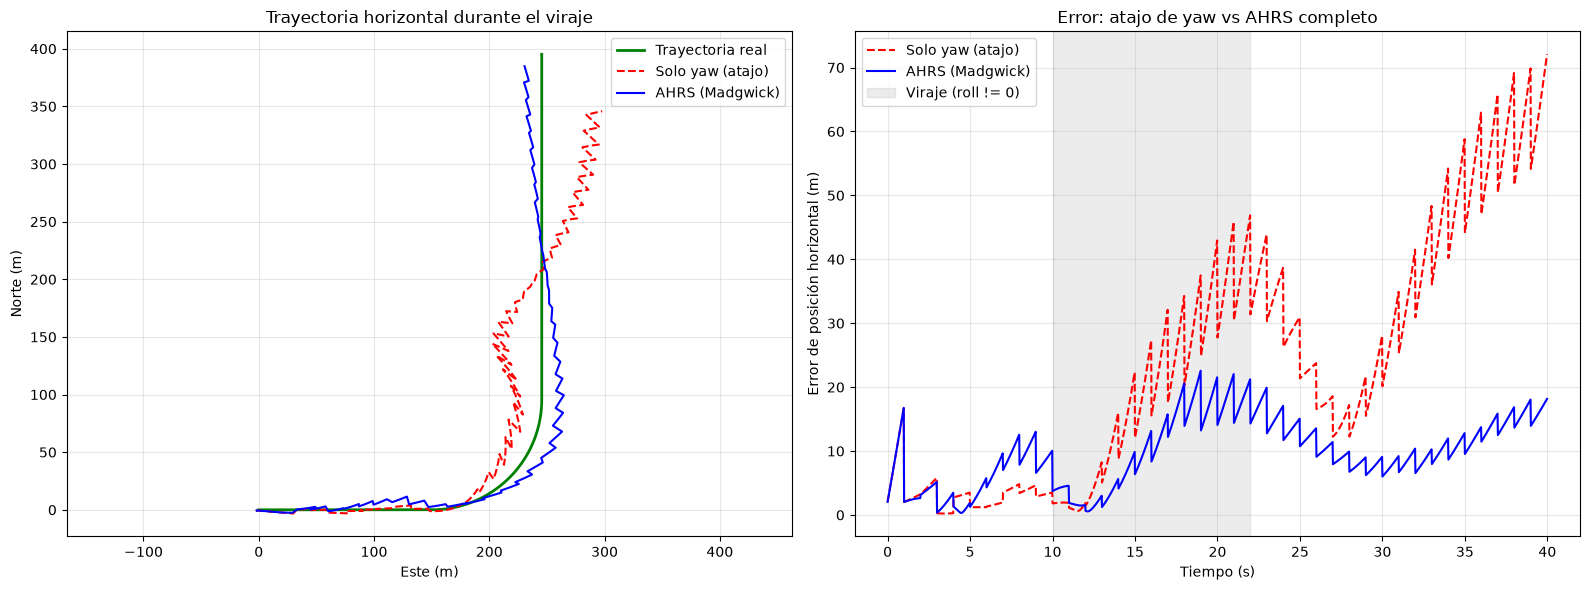

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_true_m, y_true_m, 'g-', linewidth=2, label='Trayectoria real')
axes[0].plot(x_yaw, y_yaw, 'r--', linewidth=1.5, label='Solo yaw (atajo)')
axes[0].plot(x_ahrs, y_ahrs, 'b-', linewidth=1.5, label='AHRS (Madgwick)')
axes[0].set_xlabel('Este (m)'); axes[0].set_ylabel('Norte (m)')
axes[0].set_title('Trayectoria horizontal durante el viraje')
axes[0].legend(); axes[0].axis('equal'); axes[0].grid(alpha=0.3)

axes[1].plot(t_m, err_yaw, 'r--', label='Solo yaw (atajo)')
axes[1].plot(t_m, err_ahrs, 'b-', label='AHRS (Madgwick)')
axes[1].axvspan(10, 22, color='gray', alpha=0.15, label='Viraje (roll != 0)')
axes[1].set_xlabel('Tiempo (s)'); axes[1].set_ylabel('Error de posición horizontal (m)')
axes[1].set_title('Error: atajo de yaw vs AHRS completo')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ahrs_vs_yaw.png', dpi=150)
plt.show()

### Conclusión

Fuera del viraje (roll ≈ 0), las dos reconstrucciones deberían coincidir
bastante — ahí el atajo de "solo yaw" no comete error porque su suposición
(roll/pitch ≈ 0) es cierta. Durante el viraje es donde se separan: el atajo
rota mal la aceleración medida (le falta el componente de roll), metiendo
error sistemático al filtro de posición, mientras que el AHRS lo sigue
correctamente porque sí está resolviendo la actitud completa.

Esto confirma en la práctica lo que se había marcado como pendiente: el
atajo de yaw es válido solo mientras el payload cuelga nivelado del globo.
Apenas el aeroplano vuela solo y maniobra de verdad, hace falta el AHRS. La
arquitectura recomendada para producción queda así:

```
Acelerómetro + Giroscopio + Magnetómetro
              ↓
      AHRS (Madgwick)  →  actitud completa (quaternion)
              ↓
  rota la aceleración medida al marco mundo con esa actitud
              ↓
   Filtro de Kalman GPS+IMU (crear_filtro_ca3d_bias) → posición y velocidad
```

**Pendiente**: el modelo cinemático de este viraje es ilustrativo (roll y
rumbo definidos a mano, no derivados de un modelo aerodinámico real), y la
referencia de campo magnético tampoco es la real de la zona de vuelo — ambos
hay que ajustarlos con datos reales del magnetómetro del MPU9250 en terreno.

## Próximos pasos antes de producción

- **Detección automática solo para la emergencia**: en el caso
  controlado no hace falta detectar nada — el comando de suelta ya marca el
  instante exacto en la telemetría. Para la emergencia sí conviene detectar
  el reviente en tiempo real (pico sostenido de aceleración vertical
  negativa, o caída brusca de la tasa de ascenso del barómetro BME280).
- **Filtro de modelos múltiples (IMM)**: en vez de un solo modelo de
  dinámica para todo el vuelo, mantener 2-3 modelos en paralelo (ascenso,
  caída/transición, planeo) y dejar que el propio filtro decida cuál describe
  mejor lo que está midiendo — más robusto que fijar `proceso_var` a mano.
- **Integrar el AHRS a los casos de misión**: ya está implementado y
  validado en la sección de AHRS (Madgwick) de arriba, pero corriendo aparte,
  sobre su propio escenario de viraje. Falta unirlo a `simular_escenario`
  para que los casos de emergencia/suelta también usen actitud completa (en
  vez del atajo de yaw) en las partes del vuelo donde el aeroplano ya
  maniobra solo.
- **Reemplazar los parámetros ilustrativos** de ambos escenarios (altura de
  reviente/suelta, tasas de ascenso/planeo, duración de caída libre, ruido de
  sensor) por los reales de la misión y del hardware (NEO-6M + MPU9250) apenas
  estén definidos/medidos.
- **Fusionar también el barómetro (BME280)**: ya está en el proyecto (ver
  README) y da altitud más estable que el GPS o el acelerómetro integrado en
  Z — buen candidato para otra medición más en `H`, disponible incluso
  durante el corte de GPS.
- **Última posición conocida para búsqueda**: si la telemetría se corta del
  todo (no solo el GPS), guardar de inmediato a disco la última posición,
  velocidad y matriz de incertidumbre `P` del filtro — es el punto de partida
  para estimar una zona de búsqueda si hace falta recuperar el aeroplano.
- **Portar a producción**: mover `crear_filtro_ca3d_bias` y
  `simular_escenario` (adaptado a datos reales en vez de sintéticos) a un
  módulo (p. ej. `computer/kalman.py`) e integrarlo en `bridge_server.py`
  para que, si dejan de llegar paquetes `GPS_TYPE` por más de N segundos, el
  bridge siga publicando una posición dead-reckoned (con su incertidumbre
  creciente) en vez de cortar el telemetry stream.


## Diccionario de términos

**Actitud (attitude)**: la orientación de un cuerpo en el espacio — hacia
dónde apunta y qué tan inclinado está. No es la posición (dónde está), es
cómo está rotado. Se describe con roll, pitch y yaw (ver abajo).

**AHRS** (Attitude and Heading Reference System): un sistema/algoritmo que
calcula la actitud completa (roll, pitch, yaw) fusionando acelerómetro +
giroscopio + magnetómetro. En este notebook, el AHRS usado es **Madgwick**
(ver más abajo, y la sección de procedencia del código).

**Bias**: un error fijo (o que cambia muy lento) en la lectura de un sensor,
distinto del ruido aleatorio. Un acelerómetro con bias reporta algo distinto
de cero aunque esté perfectamente quieto. Es problemático porque, al
integrarlo dos veces (aceleración → velocidad → posición), el error que
mete crece con el **cuadrado** del tiempo.

**CEP** (Circular Error Probable): una forma de medir la precisión de un GPS
— el radio dentro del cual cae el 50% de las mediciones. "2.5 m CEP"
significa que la mitad de los fixes están a menos de 2.5 m del punto real.

**Coasting**: seguir prediciendo la posición usando la última velocidad
conocida, sin ninguna medición nueva que la corrija. Es lo que hace un
filtro de solo-GPS durante un corte de señal.

**Corte de GPS / dropout**: un período sin señal GPS (por obstrucción,
vibración, etc.), donde no llegan fixes nuevos.

**Dead reckoning**: estimar la posición actual a partir de la última
posición conocida más el movimiento medido desde entonces (por ejemplo, con
un IMU), sin depender de una referencia externa como el GPS.

**Filtro de Kalman**: un algoritmo que combina una predicción (basada en un
modelo de cómo se mueve el sistema) con una medición nueva, ponderando cada
una según qué tan confiable es, para dar la mejor estimación posible del
estado real. Tiene dos pasos que se repiten: **predict** (predecir el
siguiente estado usando el modelo) y **update** (corregir esa predicción con
una medición real).

**Fix (GPS)**: una lectura de posición del receptor GPS en un instante dado.

**Giroscopio**: sensor que mide velocidad angular (qué tan rápido está
rotando algo), no orientación directamente — la orientación hay que
calcularla integrando esa velocidad en el tiempo (y por eso solo, sin
corrección, va acumulando error).

**IMU** (Inertial Measurement Unit): el sensor que combina acelerómetro +
giroscopio (y a veces magnetómetro) en un solo chip. En este proyecto es el
MPU9250.

**Marco de referencia / marco cuerpo / marco mundo**: un sistema de
coordenadas. El **marco cuerpo** está pegado al sensor (se mueve y rota con
él); el **marco mundo** es fijo respecto a la Tierra (en este notebook: este,
norte, altitud). El acelerómetro mide en marco cuerpo; para usar esa
medición hay que rotarla al marco mundo — y para eso hace falta saber la
actitud.

**Pitch (cabeceo)**: uno de los tres ángulos de la actitud — la nariz
apuntando arriba o abajo (subir/bajar).

**Quaternion**: una forma matemática de representar una rotación 3D con 4
números, más estable numéricamente que roll/pitch/yaw por separado (evita un
problema llamado *gimbal lock*). El AHRS de este notebook estima la actitud
como quaternion internamente.

**Random walk**: un valor que va cambiando de a poco, de forma aleatoria,
sin volver nunca a un punto fijo — así se modela el bias del acelerómetro en
el filtro de 9 estados (en vez de asumirlo constante).

**RMSE** (Root Mean Square Error): una forma estándar de resumir qué tan
grande es un error en promedio, a lo largo de una serie de mediciones.

**Roll (alabeo)**: uno de los tres ángulos de la actitud — inclinarse de
costado (como un avión bancando en un viraje).

**Ruido (de sensor)**: variación aleatoria en la lectura de un sensor,
distinta en cada medición. A diferencia del bias, se puede promediar/filtrar
porque no tiene una dirección fija.

**SBAS/DGPS**: sistemas de corrección que mejoran la precisión del GPS (por
ejemplo, usando una estación terrestre de referencia). El NEO-6M sin estas
correcciones tiene peor precisión (los ~2.5 m CEP usados en este notebook).

**Yaw (guiñada)**: uno de los tres ángulos de la actitud — girar quedando
nivelado (cambiar de rumbo sin inclinarse), como el atajo que usa este
notebook para las fases donde no hace falta el AHRS completo.

## Procedencia del código: qué es original y qué viene de otro lado

Para que quede claro qué código fue escrito específicamente para este
notebook y cuál viene de una fuente externa (y se pueda verificar/comparar).

### Librería externa: FilterPy
`crear_filtro_cv3d` y `crear_filtro_ca3d_bias` usan la clase `KalmanFilter`
y la función `Q_discrete_white_noise` de la librería **FilterPy**, de Roger
R. Labbe Jr. — no reimplementé el álgebra del filtro de Kalman, esa parte es
de la librería(es importante igual entender su funcionamiento teorico, en la practica de codigo se usara la libreria).

- Repositorio: [github.com/rlabbe/filterpy](https://github.com/rlabbe/filterpy)
- Documentación: [filterpy.readthedocs.io](https://filterpy.readthedocs.io/)
- Libro de referencia (gratuito) del mismo autor, de donde sale el patrón de
  filtro de velocidad constante usado acá:
  [Kalman and Bayesian Filters in Python](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python)

El **diseño específico** del filtro (qué va en el estado, el truco del bias
como estado, el control input con la aceleración del IMU, los dos
escenarios de la misión) no es una
receta copiada de un tutorial puntual.

### Algoritmo público reproducido de memoria: Madgwick AHRS
La función `madgwick_update` implementa el algoritmo de Madgwick (2010),
publicado originalmente por Sebastian O.H. Madgwick. **Importante**:lo escribí reproduciendo
el algoritmo público (se uso IA para mayor orientacion tambien). Es un algoritmo muy
replicado (aparece igual, con los mismos nombres de variables como `hx`,
`hy`, `_2bx`, `s0`-`s3`, en decenas de implementaciones), así que para que lo 
puedan comparar/verificar, estas son las referencias del algoritmo original:

- Implementación de referencia original (C#, la fuente más citada):
  [xioTechnologies/Open-Source-AHRS-With-x-IMU](https://github.com/xioTechnologies/Open-Source-AHRS-With-x-IMU/blob/master/x-IMU%20IMU%20and%20AHRS%20Algorithms/x-IMU%20IMU%20and%20AHRS%20Algorithms/AHRS/MadgwickAHRS.cs)
- Sucesor moderno mantenido por el mismo autor (ya no se llama "Madgwick",
  se llama "Fusion", pero es la evolución del mismo algoritmo):
  [xioTechnologies/Fusion](https://github.com/xioTechnologies/Fusion)
- Port a Python de otra persona, útil para comparar contra el mío:
  [morgil/madgwick_py](https://github.com/morgil/madgwick_py)
- Paper original: S.O.H. Madgwick, *"An efficient orientation filter for
  inertial and inertial/magnetic sensor arrays"*, 2010.

### Escrito específicamente para este notebook, sin fuente externa
`simular_escenario`, los parámetros de los dos casos de
misión (emergencia/suelta), el escenario del viraje con roll, y la
integración entre Madgwick y el filtro de posición.(Se uso IA para mayor comodidad de implementacion, especificamente Claude Code)

### Valores de sensor: verificados algunos, otros por revisar
- `CEP_HORIZONTAL_M = 2.5`: confirmado contra el datasheet oficial del
  NEO-6M — [NEO-6 Data Sheet, u-blox (PDF)](https://content.u-blox.com/sites/default/files/products/documents/NEO-6_DataSheet_(GPS.G6-HW-09005).pdf)
  (2.5 m CEP sin SBAS, mejora a 2.0 m con SBAS).
- `ACCEL_NOISE_STD`, `GYRO_NOISE_STD`, `ACCEL_BIAS_RESIDUAL`, `GYRO_BIAS`:
  son valores ilustrativos "razonables para un MEMS típico", **no** calculados
  a partir del datasheet real del MPU-9250. El datasheet oficial da densidad
  de ruido (ruido por raíz de Hz), que hay que convertir según la frecuencia
  de muestreo (investigar mas sobre esto...). Antes de usar estos números en serio,
  conviene recalcularlos desde la especificación oficial:
  [MPU-9250 Product Specification, InvenSense/TDK (PDF, vía SparkFun)](https://cdn.sparkfun.com/assets/learn_tutorials/5/5/0/MPU9250REV1.0.pdf)
- `M_MUNDO_REF` (referencia de campo magnético para el viraje): inventado
  para que el ejemplo funcione, no es el campo magnético real de ninguna
  ubicación — hay que reemplazarlo con mediciones reales del magnetómetro en
  terreno.